Fitting 3 folds for each of 27 candidates, totalling 81 fits
0:	learn: 2213.2913520	test: 1181.4645341	best: 1181.4645341 (0)	total: 167us	remaining: 16.6ms
99:	learn: 1774.1510399	test: 1111.3284944	best: 1098.2253436 (61)	total: 8.07ms	remaining: 0us

bestTest = 1098.225344
bestIteration = 61

Shrink model to first 62 iterations.
0:	learn: 2371.0988967	test: 1216.2444882	best: 1216.2444882 (0)	total: 116us	remaining: 11.5ms
99:	learn: 1849.3028020	test: 1022.3111290	best: 1021.6690068 (97)	total: 7.92ms	remaining: 0us

bestTest = 1021.669007
bestIteration = 97

Shrink model to first 98 iterations.
0:	learn: 1852.0601404	test: 1524.3035752	best: 1524.3035752 (0)	total: 199us	remaining: 19.8ms
99:	learn: 1514.5573306	test: 1291.5095278	best: 1291.5095278 (99)	total: 8.2ms	remaining: 0us

bestTest = 1291.509528
bestIteration = 99

0:	learn: 2194.8406312	test: 1182.4304243	best: 1182.4304243 (0)	total: 194us	remaining: 19.3ms
Stopped by overfitting detector  (50 iterations wait)

bestTes

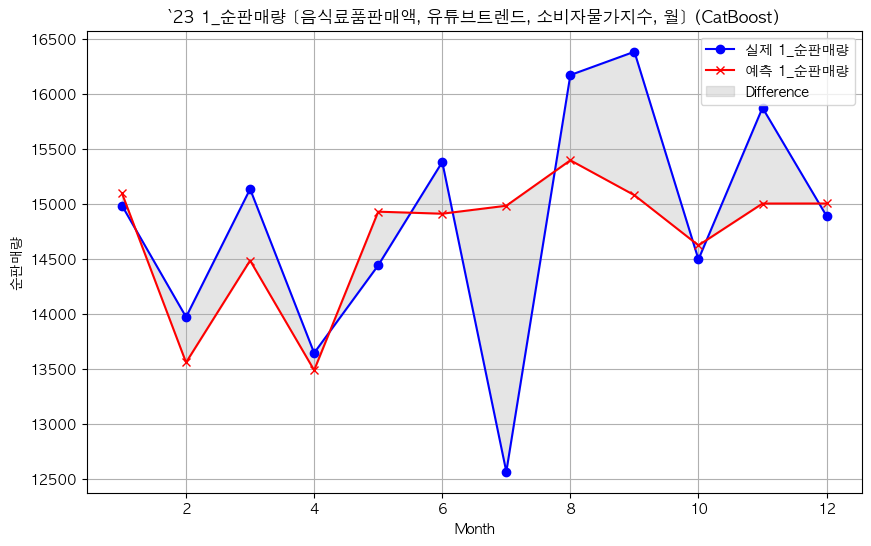

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 한글 폰트 설정
plt.rcParams['font.family'] = 'AppleGothic'

# 1. 데이터 불러오기 및 '날짜' 열에서 연도-월 정보 처리
file_path = r"../data/최종 변수.csv"
df = pd.read_csv(file_path)
df['날짜'] = df['날짜'].str[:7]  # '날짜'에서 연도-월까지만 남김
df['월'] = pd.to_datetime(df['날짜']).dt.month  # 월 변수 추가

# 2. 원핫 인코딩 (One-Hot Encoding) 적용
df = pd.get_dummies(df, columns=['월'], drop_first=True)  # 원핫 인코딩 수행, 첫 번째 월은 제외

# 중복된 열이 있는지 확인하고, 중복된 열이 있으면 제거
df = df.loc[:, ~df.columns.duplicated()]  # 중복된 열 제거

# 3. '날짜' 열을 사용하여 2021년과 2022년 데이터만 학습에 사용하고 2023년 데이터는 예측에 사용
df_train = df[df['날짜'].str[:4].isin(['2021', '2022'])]  # 학습 데이터: 2021년, 2022년
df_2023 = df[df['날짜'].str[:4].eq('2023')]  # 테스트 데이터: 2023년

# 4. 독립 변수 (X)와 종속 변수 (y) 설정
# 원핫 인코딩된 '월' 변수를 포함하여 학습
X_train = df_train[['음식료품판매액', '유튜브트렌드', '소비자물가지수'] + [col for col in df_train.columns if '월_' in col]]
y_train = df_train['1_순판매량']

X_test = df_2023[['음식료품판매액', '유튜브트렌드', '소비자물가지수'] + [col for col in df_2023.columns if '월_' in col]]
y_test = df_2023['1_순판매량']  # '1_순판매량'이 테스트 데이터의 정답값

# 5. CatBoost 모델 설정 및 하이퍼파라미터 튜닝
model = CatBoostRegressor(verbose=0)  # 기본 설정으로 CatBoostRegressor를 생성, verbose=0으로 로그 출력 안함

# 하이퍼파라미터 그리드 설정
param_grid = {
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'iterations': [100, 500, 1000]
}

# GridSearchCV에서 얼리스탑핑을 위해 fit_params 추가
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, scoring='neg_mean_squared_error', cv=3, verbose=1)

# 모델 학습 및 얼리스탑핑 적용
grid_search.fit(X_train, y_train, early_stopping_rounds=50, eval_set=(X_test, y_test), verbose=100)

# 최적의 하이퍼파라미터 출력
print("최적의 하이퍼파라미터: ", grid_search.best_params_)

# 6. 최적의 모델로 2023년 데이터 예측
best_model = grid_search.best_estimator_
pred_2023 = best_model.predict(X_test)

# 7. 예측 결과 출력
print("`23 1_순판매량 [음식료품판매액, 유튜브트렌드, 소비자물가지수, 월] (CatBoost)")
print(pred_2023)

# 8. 실제값과 비교 및 MSE, MAE 계산
if '1_순판매량' in df_2023.columns:
    actual_2023 = df_2023['1_순판매량'].values
    mse = mean_squared_error(actual_2023, pred_2023)
    mae = mean_absolute_error(actual_2023, pred_2023)
    print(f"2023년 데이터의 실제값과 예측값의 MSE: {mse}")
    print(f"2023년 데이터의 실제값과 예측값의 MAE: {mae}")
else:
    print("2023년 데이터에 대한 실제값이 없으므로, 비교할 수 없습니다.")

# 9. 그래프 그리기
actual_2023 = df_2023['1_순판매량'].values
months_2023 = np.arange(1, len(actual_2023) + 1)

plt.figure(figsize=(10, 6))
plt.plot(months_2023, actual_2023, label='실제 1_순판매량', marker='o', color='b')
plt.plot(months_2023, pred_2023, label='예측 1_순판매량', marker='x', color='r')
plt.fill_between(months_2023, actual_2023, pred_2023, color='gray', alpha=0.2, label='Difference')

plt.xlabel('Month')
plt.ylabel('순판매량')
plt.title('`23 1_순판매량 [음식료품판매액, 유튜브트렌드, 소비자물가지수, 월] (CatBoost)')
plt.legend()
plt.grid(True)
plt.show()

In [5]:
grid_search.best_params_

{'depth': 4, 'iterations': 500, 'learning_rate': 0.05}

In [6]:
best_model

In [7]:
# 1. 데이터 불러오기 및 '날짜' 열에서 연도-월 정보 처리
df = pd.read_csv(file_path)
df['날짜'] = df['날짜'].str[:7]  # '날짜'에서 연도-월까지만 남김
df['월'] = pd.to_datetime(df['날짜']).dt.month  # 월 변수 추가

# 2. 원핫 인코딩 (One-Hot Encoding) 적용
df = pd.get_dummies(df, columns=['월'], drop_first=True)  # 원핫 인코딩 수행, 첫 번째 월은 제외

# 중복된 열이 있는지 확인하고, 중복된 열이 있으면 제거
df = df.loc[:, ~df.columns.duplicated()]  # 중복된 열 제거

# 3. '날짜' 열을 사용하여 2021년과 2022년 데이터만 학습에 사용하고 2023년과 2024년 데이터는 예측에 사용
df_train_21_22 = df[df['날짜'].str[:4].isin(['2021', '2022'])]  # 학습 데이터: 2021년, 2022년
df_train_21_23 = df[df['날짜'].str[:4].isin(['2021', '2022', '2023'])]  # 학습 데이터: 2021년, 2022년
df_test_23_24 = df[df['날짜'].str[:4].isin(['2023', '2024'])]  # 테스트 데이터: 2023년, 2024년
df_test_2023 = df[df['날짜'].str[:4].eq('2023')]  # 테스트 데이터: 2023년
df_test_2024 = df[df['날짜'].str[:4].eq('2024')]  # 테스트 데이터: 2024년

# 각 데이터셋에서도 중복된 열 제거
df_train_21_22 = df_train_21_22.loc[:, ~df_train_21_22.columns.duplicated()]
df_train_21_23 = df_train_21_23.loc[:, ~df_train_21_23.columns.duplicated()]
df_test_23_24 = df_test_23_24.loc[:, ~df_test_23_24.columns.duplicated()]
df_test_2023 = df_test_2023.loc[:, ~df_test_2023.columns.duplicated()]
df_test_2024 = df_test_2024.loc[:, ~df_test_2024.columns.duplicated()]

# 4. 독립 변수 (X)와 종속 변수 (y) 설정
X_train_21_22 = df_train_21_22[['음식료품판매액', '유튜브트렌드', '소비자물가지수'] + [col for col in df_train_21_22.columns if '월_' in col]]
y_train_21_22 = df_train_21_22['1_순판매량']

X_train_21_23 = df_train_21_23[['음식료품판매액', '유튜브트렌드', '소비자물가지수'] + [col for col in df_train_21_22.columns if '월_' in col]]
y_train_21_23 = df_train_21_23['1_순판매량']

X_test_2023 = df_test_2023[['음식료품판매액', '유튜브트렌드', '소비자물가지수'] + [col for col in df_test_2023.columns if '월_' in col]]
y_test_2023 = df_test_2023['1_순판매량']

X_test_2024 = df_test_2024[['음식료품판매액', '유튜브트렌드', '소비자물가지수'] + [col for col in df_test_2024.columns if '월_' in col]]

X_test_23_24 = df_test_23_24[['음식료품판매액', '유튜브트렌드', '소비자물가지수'] + [col for col in df_test_2024.columns if '월_' in col]]

# 5. CatBoost 모델 설정 및 하이퍼파라미터 튜닝
model = CatBoostRegressor(verbose=0)  # 기본 설정으로 CatBoostRegressor를 생성, verbose=0으로 로그 출력 안함

# 하이퍼파라미터 그리드 설정
param_grid = {
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'iterations': [100, 500, 1000]
}

# GridSearchCV에서 얼리스탑핑을 위해 fit_params 추가
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, scoring='neg_mean_squared_error', cv=3, verbose=1)

# 모델 학습 및 얼리스탑핑 적용 (2021~2022년 데이터로 학습)
grid_search.fit(X_train_21_22, y_train_21_22, early_stopping_rounds=50, eval_set=(X_test_2023, y_test_2023), verbose=100)

# 최적의 하이퍼파라미터 출력
print("최적의 하이퍼파라미터: ", grid_search.best_params_)

# 6. 최적의 모델로 2023년 데이터 예측
best_model = grid_search.best_estimator_
pred_2023 = best_model.predict(X_test_2023)
pred_23_24 = best_model.predict(X_test_23_24)


# 7. 예측 결과 출력
print("`23 1_순판매량 [음식료품판매액, 유튜브트렌드, 소비자물가지수, 월] (CatBoost)")
print(pred_2023)

# 8. 실제값과 비교 및 MSE, MAE 계산
if '1_순판매량' in df_test_2023.columns:
    actual_2023 = df_test_2023['1_순판매량'].values
    mse = mean_squared_error(actual_2023, pred_2023)
    mae = mean_absolute_error(actual_2023, pred_2023)
    print(f"2023년 데이터의 실제값과 예측값의 MSE: {mse}")
    print(f"2023년 데이터의 실제값과 예측값의 MAE: {mae}")
else:
    print("2023년 데이터에 대한 실제값이 없으므로, 비교할 수 없습니다.")

# 9. 2024년 데이터 예측
pred_2024 = best_model.predict(X_test_2024)
print("`24 1_순판매량 예측값 (CatBoost)")
print(pred_2024)




Fitting 3 folds for each of 27 candidates, totalling 81 fits
0:	learn: 2213.2913520	test: 1181.4645341	best: 1181.4645341 (0)	total: 101us	remaining: 10.1ms
99:	learn: 1774.1510399	test: 1111.3284944	best: 1098.2253436 (61)	total: 9.09ms	remaining: 0us

bestTest = 1098.225344
bestIteration = 61

Shrink model to first 62 iterations.
0:	learn: 2371.0988967	test: 1216.2444882	best: 1216.2444882 (0)	total: 117us	remaining: 11.6ms
99:	learn: 1849.3028020	test: 1022.3111290	best: 1021.6690068 (97)	total: 8.99ms	remaining: 0us

bestTest = 1021.669007
bestIteration = 97

Shrink model to first 98 iterations.
0:	learn: 1852.0601404	test: 1524.3035752	best: 1524.3035752 (0)	total: 182us	remaining: 18ms
99:	learn: 1514.5573306	test: 1291.5095278	best: 1291.5095278 (99)	total: 9.73ms	remaining: 0us

bestTest = 1291.509528
bestIteration = 99

0:	learn: 2194.8406312	test: 1182.4304243	best: 1182.4304243 (0)	total: 104us	remaining: 10.4ms
Stopped by overfitting detector  (50 iterations wait)

bestTest

In [8]:
# 1. 데이터 불러오기 및 '날짜' 열에서 연도-월 정보 처리
df = pd.read_csv(file_path)
df['날짜'] = df['날짜'].str[:7]  # '날짜'에서 연도-월까지만 남김
df['월'] = pd.to_datetime(df['날짜']).dt.month  # 월 변수 추가

# 2. 원핫 인코딩 (One-Hot Encoding) 적용
df = pd.get_dummies(df, columns=['월'], drop_first=True)  # 원핫 인코딩 수행, 첫 번째 월은 제외

# 중복된 열이 있는지 확인하고, 중복된 열이 있으면 제거
df = df.loc[:, ~df.columns.duplicated()]  # 중복된 열 제거

# 3. '날짜' 열을 사용하여 2021년과 2022년 데이터만 학습에 사용하고 2023년과 2024년 데이터는 예측에 사용
df_train_21_22 = df[df['날짜'].str[:4].isin(['2021', '2022'])]  # 학습 데이터: 2021년, 2022년
df_train_21_23 = df[df['날짜'].str[:4].isin(['2021', '2022', '2023'])]  # 학습 데이터: 2021년, 2022년
df_test_23_24 = df[df['날짜'].str[:4].isin(['2023', '2024'])]  # 테스트 데이터: 2023년, 2024년
df_test_2023 = df[df['날짜'].str[:4].eq('2023')]  # 테스트 데이터: 2023년
df_test_2024 = df[df['날짜'].str[:4].eq('2024')]  # 테스트 데이터: 2024년

# 각 데이터셋에서도 중복된 열 제거
df_train_21_22 = df_train_21_22.loc[:, ~df_train_21_22.columns.duplicated()]
df_train_21_23 = df_train_21_23.loc[:, ~df_train_21_23.columns.duplicated()]
df_test_23_24 = df_test_23_24.loc[:, ~df_test_23_24.columns.duplicated()]
df_test_2023 = df_test_2023.loc[:, ~df_test_2023.columns.duplicated()]
df_test_2024 = df_test_2024.loc[:, ~df_test_2024.columns.duplicated()]

# 4. 독립 변수 (X)와 종속 변수 (y) 설정
X_train_21_22 = df_train_21_22[['음식료품판매액', '유튜브트렌드', '소비자물가지수'] + [col for col in df_train_21_22.columns if '월_' in col]]
y_train_21_22 = df_train_21_22['1_순판매량']

X_train_21_23 = df_train_21_23[['음식료품판매액', '유튜브트렌드', '소비자물가지수'] + [col for col in df_train_21_22.columns if '월_' in col]]
y_train_21_23 = df_train_21_23['1_순판매량']

X_test_2023 = df_test_2023[['음식료품판매액', '유튜브트렌드', '소비자물가지수'] + [col for col in df_test_2023.columns if '월_' in col]]
y_test_2023 = df_test_2023['1_순판매량']

X_test_2024 = df_test_2024[['음식료품판매액', '유튜브트렌드', '소비자물가지수'] + [col for col in df_test_2024.columns if '월_' in col]]

X_test_23_24 = df_test_23_24[['음식료품판매액', '유튜브트렌드', '소비자물가지수'] + [col for col in df_test_2024.columns if '월_' in col]]

# 5. CatBoost 모델 설정 및 하이퍼파라미터 튜닝
model = CatBoostRegressor(verbose=0)  # 기본 설정으로 CatBoostRegressor를 생성, verbose=0으로 로그 출력 안함

# 하이퍼파라미터 그리드 설정
param_grid = {
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'iterations': [100, 500, 1000]
}

# GridSearchCV에서 얼리스탑핑을 위해 fit_params 추가
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, scoring='neg_mean_squared_error', cv=3, verbose=1)

# 모델 학습 및 얼리스탑핑 적용 (2021~2022년 데이터로 학습)
grid_search.fit(X_train_21_22, y_train_21_22, early_stopping_rounds=50, eval_set=(X_test_2023, y_test_2023), verbose=100)

# 최적의 하이퍼파라미터 출력
print("최적의 하이퍼파라미터: ", grid_search.best_params_)

# 6. 최적의 모델로 2023년 데이터 예측
best_model = grid_search.best_estimator_
model_21_22 = best_model
model_21_22.fit(X_train_21_22, y_train_21_22)
pred_2023 = model_21_22.predict(X_test_2023)
pred_23_24 = model_21_22.predict(X_test_23_24)


# 7. 예측 결과 출력
print("`23 1_순판매량 [음식료품판매액, 유튜브트렌드, 소비자물가지수, 월] (CatBoost)")
print(pred_2023)

# 8. 실제값과 비교 및 MSE, MAE 계산
if '1_순판매량' in df_test_2023.columns:
    actual_2023 = df_test_2023['1_순판매량'].values
    mse = mean_squared_error(actual_2023, pred_2023)
    mae = mean_absolute_error(actual_2023, pred_2023)
    print(f"2023년 데이터의 실제값과 예측값의 MSE: {mse}")
    print(f"2023년 데이터의 실제값과 예측값의 MAE: {mae}")
else:
    print("2023년 데이터에 대한 실제값이 없으므로, 비교할 수 없습니다.")

# 9. 2024년 데이터 예측
pred_2024 = best_model.predict(X_test_2024)
print("`24 1_순판매량 예측값 (CatBoost)")
print(pred_2024)




Fitting 3 folds for each of 27 candidates, totalling 81 fits
0:	learn: 2213.2913520	test: 1181.4645341	best: 1181.4645341 (0)	total: 109us	remaining: 10.9ms
99:	learn: 1774.1510399	test: 1111.3284944	best: 1098.2253436 (61)	total: 8.63ms	remaining: 0us

bestTest = 1098.225344
bestIteration = 61

Shrink model to first 62 iterations.
0:	learn: 2371.0988967	test: 1216.2444882	best: 1216.2444882 (0)	total: 69us	remaining: 6.86ms
99:	learn: 1849.3028020	test: 1022.3111290	best: 1021.6690068 (97)	total: 8.53ms	remaining: 0us

bestTest = 1021.669007
bestIteration = 97

Shrink model to first 98 iterations.
0:	learn: 1852.0601404	test: 1524.3035752	best: 1524.3035752 (0)	total: 107us	remaining: 10.6ms
99:	learn: 1514.5573306	test: 1291.5095278	best: 1291.5095278 (99)	total: 8.74ms	remaining: 0us

bestTest = 1291.509528
bestIteration = 99

0:	learn: 2194.8406312	test: 1182.4304243	best: 1182.4304243 (0)	total: 80us	remaining: 7.94ms
Stopped by overfitting detector  (50 iterations wait)

bestTest

In [9]:
# 1. 데이터 불러오기 및 '날짜' 열에서 연도-월 정보 처리
df = pd.read_csv(file_path)
df['날짜'] = df['날짜'].str[:7]  # '날짜'에서 연도-월까지만 남김
df['월'] = pd.to_datetime(df['날짜']).dt.month  # 월 변수 추가

# 2. 원핫 인코딩 (One-Hot Encoding) 적용
df = pd.get_dummies(df, columns=['월'], drop_first=True)  # 원핫 인코딩 수행, 첫 번째 월은 제외

# 중복된 열이 있는지 확인하고, 중복된 열이 있으면 제거
df = df.loc[:, ~df.columns.duplicated()]  # 중복된 열 제거

# 3. '날짜' 열을 사용하여 2021년과 2022년 데이터만 학습에 사용하고 2023년과 2024년 데이터는 예측에 사용
df_train_21_22 = df[df['날짜'].str[:4].isin(['2021', '2022'])]  # 학습 데이터: 2021년, 2022년
df_train_21_23 = df[df['날짜'].str[:4].isin(['2021', '2022', '2023'])]  # 학습 데이터: 2021년, 2022년, 2023년
df_test_23_24 = df[df['날짜'].str[:4].isin(['2023', '2024'])]  # 테스트 데이터: 2023년, 2024년
df_test_2023 = df[df['날짜'].str[:4].eq('2023')]  # 테스트 데이터: 2023년
df_test_2024 = df[df['날짜'].str[:4].eq('2024')]  # 테스트 데이터: 2024년

# 각 데이터셋에서도 중복된 열 제거
df_train_21_22 = df_train_21_22.loc[:, ~df_train_21_22.columns.duplicated()]
df_train_21_23 = df_train_21_23.loc[:, ~df_train_21_23.columns.duplicated()]
df_test_23_24 = df_test_23_24.loc[:, ~df_test_23_24.columns.duplicated()]
df_test_2023 = df_test_2023.loc[:, ~df_test_2023.columns.duplicated()]
df_test_2024 = df_test_2024.loc[:, ~df_test_2024.columns.duplicated()]

# 4. 독립 변수 (X)와 종속 변수 (y) 설정
X_train_21_22 = df_train_21_22[['음식료품판매액', '유튜브트렌드', '소비자물가지수'] + [col for col in df_train_21_22.columns if '월_' in col]]
y_train_21_22 = df_train_21_22['1_순판매량']

X_train_21_23 = df_train_21_23[['음식료품판매액', '유튜브트렌드', '소비자물가지수'] + [col for col in df_train_21_22.columns if '월_' in col]]
y_train_21_23 = df_train_21_23['1_순판매량']

X_test_2023 = df_test_2023[['음식료품판매액', '유튜브트렌드', '소비자물가지수'] + [col for col in df_test_2023.columns if '월_' in col]]
y_test_2023 = df_test_2023['1_순판매량']

X_test_2024 = df_test_2024[['음식료품판매액', '유튜브트렌드', '소비자물가지수'] + [col for col in df_test_2024.columns if '월_' in col]]

X_test_23_24 = df_test_23_24[['음식료품판매액', '유튜브트렌드', '소비자물가지수'] + [col for col in df_test_2024.columns if '월_' in col]]

# 5. CatBoost 모델 설정 및 하이퍼파라미터 튜닝
model = CatBoostRegressor(verbose=0)  # 기본 설정으로 CatBoostRegressor를 생성, verbose=0으로 로그 출력 안함

# 하이퍼파라미터 그리드 설정
param_grid = {
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'iterations': [100, 500, 1000]
}

# GridSearchCV에서 얼리스탑핑을 위해 fit_params 추가
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, scoring='neg_mean_squared_error', cv=3, verbose=1)

# 모델 학습 및 얼리스탑핑 적용 (2021~2022년 데이터로 학습)
grid_search.fit(X_train_21_22, y_train_21_22, early_stopping_rounds=50, eval_set=(X_test_2023, y_test_2023), verbose=100)

# 최적의 하이퍼파라미터 출력
print("최적의 하이퍼파라미터: ", grid_search.best_params_)

# 6. 최적의 모델로 2023년 데이터 예측
best_model = grid_search.best_estimator_
pred_2023 = best_model.predict(X_test_2023)
pred_23_24 = best_model.predict(X_test_23_24)

# 7. 예측 결과 출력
print("`23 1_순판매량 [음식료품판매액, 유튜브트렌드, 소비자물가지수, 월] (CatBoost)")
print(pred_2023)

# 8. 실제값과 비교 및 MSE, MAE 계산
if '1_순판매량' in df_test_2023.columns:
    actual_2023 = df_test_2023['1_순판매량'].values
    mse = mean_squared_error(actual_2023, pred_2023)
    mae = mean_absolute_error(actual_2023, pred_2023)
    print(f"2023년 데이터의 실제값과 예측값의 MSE: {mse}")
    print(f"2023년 데이터의 실제값과 예측값의 MAE: {mae}")
else:
    print("2023년 데이터에 대한 실제값이 없으므로, 비교할 수 없습니다.")

# 9. 2024년 데이터 예측
pred_2024 = best_model.predict(X_test_2024)
print("`24 1_순판매량 예측값 (CatBoost)")
print(pred_2024)

# 여기서부터 추가된 코드

# 10. 21년과 22년 데이터로 2023년과 2024년 예측
best_model_21_22 = grid_search.best_estimator_

# 2023년과 2024년 데이터를 예측
pred_23_24_21_22 = best_model_21_22.predict(X_test_23_24)

# 예측 결과 출력
print("21년, 22년 데이터로 예측한 2023년과 2024년 1_순판매량 (CatBoost)")
print(pred_23_24_21_22)

# 11. 21년, 22년, 23년 데이터를 사용하여 2024년을 예측
grid_search.fit(X_train_21_23, y_train_21_23, early_stopping_rounds=50, eval_set=(X_test_2024, np.zeros(len(X_test_2024))), verbose=100)
best_model_21_23 = grid_search.best_estimator_

# 2024년 데이터 예측
pred_2024_21_23 = best_model_21_23.predict(X_test_2024)

# 예측 결과 출력
print("21년, 22년, 23년 데이터로 예측한 2024년 1_순판매량 (CatBoost)")
print(pred_2024_21_23)

Fitting 3 folds for each of 27 candidates, totalling 81 fits
0:	learn: 2213.2913520	test: 1181.4645341	best: 1181.4645341 (0)	total: 101us	remaining: 10ms
99:	learn: 1774.1510399	test: 1111.3284944	best: 1098.2253436 (61)	total: 8.32ms	remaining: 0us

bestTest = 1098.225344
bestIteration = 61

Shrink model to first 62 iterations.
0:	learn: 2371.0988967	test: 1216.2444882	best: 1216.2444882 (0)	total: 52us	remaining: 5.23ms
99:	learn: 1849.3028020	test: 1022.3111290	best: 1021.6690068 (97)	total: 9.2ms	remaining: 0us

bestTest = 1021.669007
bestIteration = 97

Shrink model to first 98 iterations.
0:	learn: 1852.0601404	test: 1524.3035752	best: 1524.3035752 (0)	total: 68us	remaining: 6.78ms
99:	learn: 1514.5573306	test: 1291.5095278	best: 1291.5095278 (99)	total: 8.55ms	remaining: 0us

bestTest = 1291.509528
bestIteration = 99

0:	learn: 2194.8406312	test: 1182.4304243	best: 1182.4304243 (0)	total: 55us	remaining: 5.53ms
Stopped by overfitting detector  (50 iterations wait)

bestTest = 9

In [10]:
pred_2023

array([15095.14310652, 13556.57788026, 14483.96480688, 13486.3153595 ,
       14928.19929749, 14909.71739393, 14982.2477098 , 15395.57838802,
       15078.07314989, 14621.70690798, 15002.22296109, 15002.58150388])

In [11]:
pred_combined_23_24 = np.concatenate([pred_2023, pred_2024])

In [12]:
pred_combined_23_24

array([15095.14310652, 13556.57788026, 14483.96480688, 13486.3153595 ,
       14928.19929749, 14909.71739393, 14982.2477098 , 15395.57838802,
       15078.07314989, 14621.70690798, 15002.22296109, 15002.58150388,
       15070.30097147, 14909.99924793, 14436.84063689, 14358.34315515,
       14508.67475984, 14484.42672276])

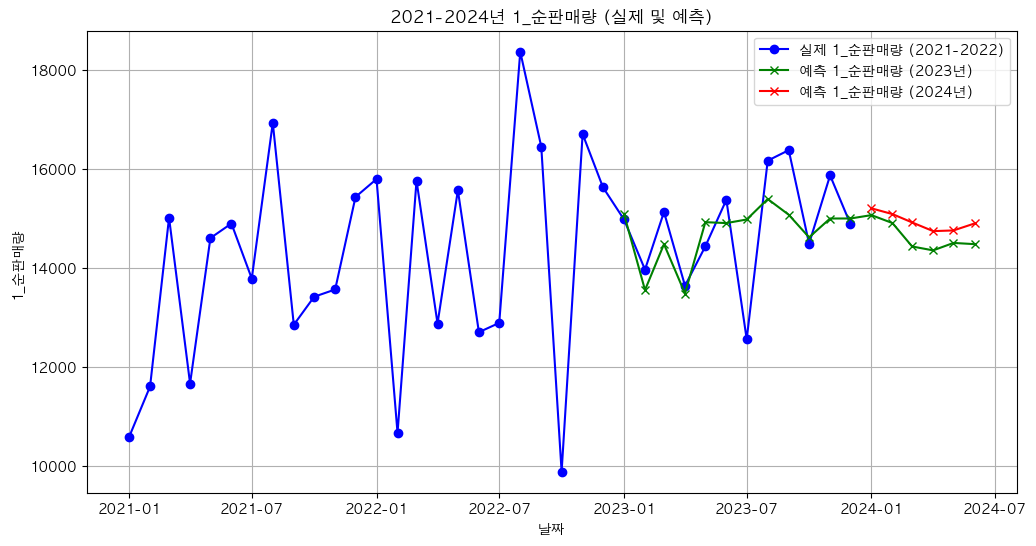

In [13]:
# 10. 그래프 그리기
# 2021~2023년 실제 데이터
df_train_21_23 = df[df['날짜'].str[:4].isin(['2021', '2022', '2023'])]  # 학습 데이터: 2021년, 2022년

dates_train = pd.to_datetime(df_train_21_23['날짜'])
sales_train = df_train_21_23['1_순판매량']

# 2023년 예측 데이터
dates_test_2023 = pd.to_datetime(df_test_2023['날짜'])
sales_pred_2023 = pred_2023

# 2024년 예측 데이터
dates_test_2024 = pd.to_datetime(df_test_2024['날짜'])
sales_pred_2024 = pred_2024_21_23

dates_test_23_24 = pd.to_datetime(df_test_23_24['날짜'])
sales_pred_23_24 = pred_combined_23_24

plt.figure(figsize=(12, 6))

# 2021~2022년 실제 데이터 그래프
plt.plot(dates_train, sales_train, label='실제 1_순판매량 (2021-2022)', marker='o', color='b')

# 2023년 예측 데이터 그래프
plt.plot(dates_test_23_24, sales_pred_23_24, label='예측 1_순판매량 (2023년)', marker='x', color='g')

# 2024년 예측 데이터 그래프
plt.plot(dates_test_2024, sales_pred_2024, label='예측 1_순판매량 (2024년)', marker='x', color='r')

# 그래프 설정
plt.xlabel('날짜')
plt.ylabel('1_순판매량')
plt.title('2021-2024년 1_순판매량 (실제 및 예측)')
plt.legend()
plt.grid(True)

# 그래프 표시
plt.show()

In [14]:
sales_pred_2024

array([15207.57014451, 15091.39511429, 14922.65799486, 14747.34970026,
       14761.09612045, 14901.39032192])

Fitting 3 folds for each of 27 candidates, totalling 81 fits
2023년 Gradient Boosting MSE: 2534820.9543324285
2023년 Gradient Boosting MAE: 1206.3414411490355


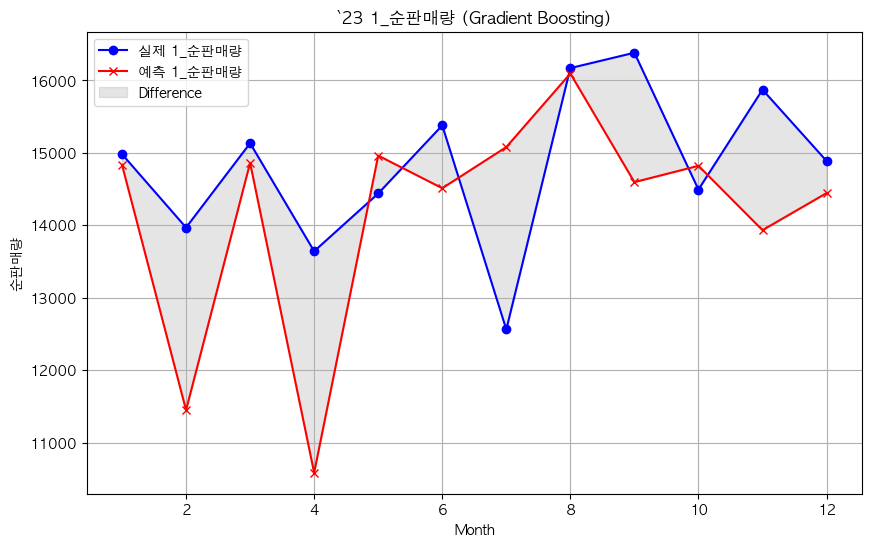

In [15]:
from sklearn.ensemble import GradientBoostingRegressor

# 5. Gradient Boosting 모델 설정 및 하이퍼파라미터 튜닝
model = GradientBoostingRegressor()

# 하이퍼파라미터 그리드 설정
param_grid = {
    'n_estimators': [100, 500, 1000],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
}

grid_search = GridSearchCV(estimator=model, param_grid=param_grid, scoring='neg_mean_squared_error', cv=3, verbose=1)
grid_search.fit(X_train, y_train)

# 최적의 모델로 2023년 데이터 예측
best_model = grid_search.best_estimator_
pred_2023 = best_model.predict(X_test)

# 실제값과 비교 및 MSE, MAE 계산
actual_2023 = df_2023['1_순판매량'].values
mse = mean_squared_error(actual_2023, pred_2023)
mae = mean_absolute_error(actual_2023, pred_2023)
print(f"2023년 Gradient Boosting MSE: {mse}")
print(f"2023년 Gradient Boosting MAE: {mae}")

# 그래프 그리기
months_2023 = np.arange(1, len(actual_2023) + 1)
plt.figure(figsize=(10, 6))
plt.plot(months_2023, actual_2023, label='실제 1_순판매량', marker='o', color='b')
plt.plot(months_2023, pred_2023, label='예측 1_순판매량', marker='x', color='r')
plt.fill_between(months_2023, actual_2023, pred_2023, color='gray', alpha=0.2, label='Difference')
plt.xlabel('Month')
plt.ylabel('순판매량')
plt.title('`23 1_순판매량 (Gradient Boosting)')
plt.legend()
plt.grid(True)
plt.show()


Fitting 3 folds for each of 27 candidates, totalling 81 fits
2023년 XGBoost MSE: 2811574.3232655525
2023년 XGBoost MAE: 1340.2386067708333


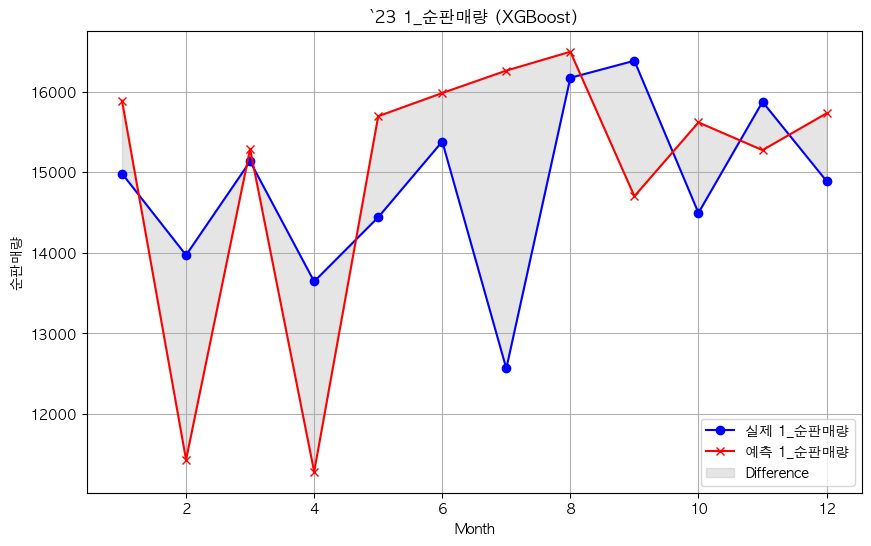

In [16]:
from xgboost import XGBRegressor

# 5. XGBoost 모델 설정 및 하이퍼파라미터 튜닝
model = XGBRegressor()

# 하이퍼파라미터 그리드 설정
param_grid = {
    'n_estimators': [100, 500, 1000],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
}

grid_search = GridSearchCV(estimator=model, param_grid=param_grid, scoring='neg_mean_squared_error', cv=3, verbose=1)
grid_search.fit(X_train, y_train)

# 최적의 모델로 2023년 데이터 예측
best_model = grid_search.best_estimator_
pred_2023 = best_model.predict(X_test)

# 실제값과 비교 및 MSE, MAE 계산
actual_2023 = df_2023['1_순판매량'].values
mse = mean_squared_error(actual_2023, pred_2023)
mae = mean_absolute_error(actual_2023, pred_2023)
print(f"2023년 XGBoost MSE: {mse}")
print(f"2023년 XGBoost MAE: {mae}")

# 그래프 그리기
months_2023 = np.arange(1, len(actual_2023) + 1)
plt.figure(figsize=(10, 6))
plt.plot(months_2023, actual_2023, label='실제 1_순판매량', marker='o', color='b')
plt.plot(months_2023, pred_2023, label='예측 1_순판매량', marker='x', color='r')
plt.fill_between(months_2023, actual_2023, pred_2023, color='gray', alpha=0.2, label='Difference')
plt.xlabel('Month')
plt.ylabel('순판매량')
plt.title('`23 1_순판매량 (XGBoost)')
plt.legend()
plt.grid(True)
plt.show()

Fitting 3 folds for each of 27 candidates, totalling 81 fits
2023년 Random Forest MSE: 1183550.334539052
2023년 Random Forest MAE: 873.8645806989322


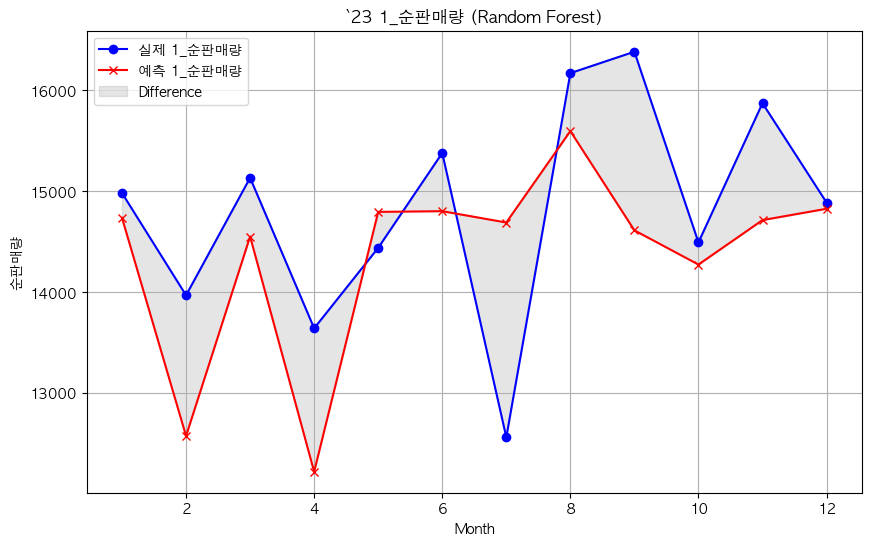

In [17]:
from sklearn.ensemble import RandomForestRegressor

# 5. Random Forest 모델 설정 및 하이퍼파라미터 튜닝
model = RandomForestRegressor()

# 하이퍼파라미터 그리드 설정
param_grid = {
    'n_estimators': [100, 500, 1000],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(estimator=model, param_grid=param_grid, scoring='neg_mean_squared_error', cv=3, verbose=1)
grid_search.fit(X_train, y_train)

# 최적의 모델로 2023년 데이터 예측
best_model = grid_search.best_estimator_
pred_2023 = best_model.predict(X_test)

# 실제값과 비교 및 MSE, MAE 계산
actual_2023 = df_2023['1_순판매량'].values
mse = mean_squared_error(actual_2023, pred_2023)
mae = mean_absolute_error(actual_2023, pred_2023)
print(f"2023년 Random Forest MSE: {mse}")
print(f"2023년 Random Forest MAE: {mae}")

# 그래프 그리기
months_2023 = np.arange(1, len(actual_2023) + 1)
plt.figure(figsize=(10, 6))
plt.plot(months_2023, actual_2023, label='실제 1_순판매량', marker='o', color='b')
plt.plot(months_2023, pred_2023, label='예측 1_순판매량', marker='x', color='r')
plt.fill_between(months_2023, actual_2023, pred_2023, color='gray', alpha=0.2, label='Difference')
plt.xlabel('Month')
plt.ylabel('순판매량')
plt.title('`23 1_순판매량 (Random Forest)')
plt.legend()
plt.grid(True)
plt.show()


2023년 선형 회귀 MSE: 2431464.752849933
2023년 선형 회귀 MAE: 1346.4695886931086


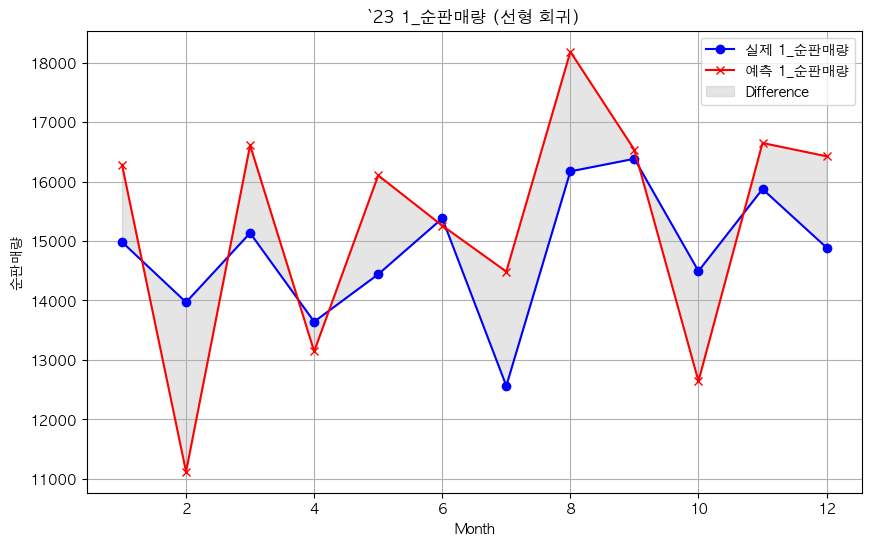

In [18]:
from sklearn.linear_model import LinearRegression

# 5. 선형 회귀 모델 설정 및 학습
model = LinearRegression()
model.fit(X_train, y_train)

# 2023년 데이터 예측
pred_2023 = model.predict(X_test)

# 실제값과 비교 및 MSE, MAE 계산
actual_2023 = df_2023['1_순판매량'].values
mse = mean_squared_error(actual_2023, pred_2023)
mae = mean_absolute_error(actual_2023, pred_2023)
print(f"2023년 선형 회귀 MSE: {mse}")
print(f"2023년 선형 회귀 MAE: {mae}")

# 그래프 그리기
months_2023 = np.arange(1, len(actual_2023) + 1)
plt.figure(figsize=(10, 6))
plt.plot(months_2023, actual_2023, label='실제 1_순판매량', marker='o', color='b')
plt.plot(months_2023, pred_2023, label='예측 1_순판매량', marker='x', color='r')
plt.fill_between(months_2023, actual_2023, pred_2023, color='gray', alpha=0.2, label='Difference')
plt.xlabel('Month')
plt.ylabel('순판매량')
plt.title('`23 1_순판매량 (선형 회귀)')
plt.legend()
plt.grid(True)
plt.show()


MLPRegressor 2023년 데이터의 MSE: 73124211.98249583
MLPRegressor 2023년 데이터의 MAE: 8473.249651527238


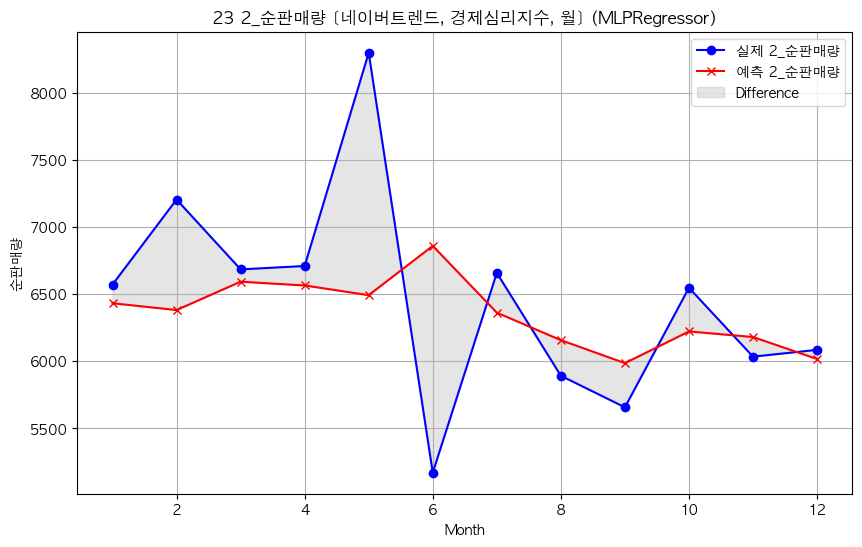

In [19]:
from sklearn.neural_network import MLPRegressor

# 1. 데이터 불러오기 및 '날짜' 열에서 연도-월 정보 처리
df = pd.read_csv(file_path)
df['날짜'] = df['날짜'].str[:7]  # '날짜'에서 연도-월까지만 남김
df['월'] = pd.to_datetime(df['날짜']).dt.month  # 월 변수 추가

# 2. 원핫 인코딩 (One-Hot Encoding) 적용
df = pd.get_dummies(df, columns=['월'], drop_first=True)  # 원핫 인코딩 수행, 첫 번째 월은 제외

# 중복된 열이 있는지 확인하고, 중복된 열이 있으면 제거
df = df.loc[:, ~df.columns.duplicated()]  # 중복된 열 제거

# 3. '날짜' 열을 사용하여 2021년과 2022년 데이터만 학습에 사용하고 2023년 데이터는 예측에 사용
df_21_22 = df[df['날짜'].str[:4].isin(['2021', '2022'])] 
df_21_23 = df[df['날짜'].str[:4].isin(['2021', '2022', '2023'])] 
df_23_24 = df[df['날짜'].str[:4].isin(['2023', '2024'])] 
df_23 = df[df['날짜'].str[:4].eq('2023')] 
df_24 = df[df['날짜'].str[:4].eq('2024')] 

# 각 데이터셋에서도 중복된 열 제거
df_21_22 = df_21_22.loc[:, ~df_21_22.columns.duplicated()]
df_21_23 = df_21_23.loc[:, ~df_21_23.columns.duplicated()]
df_23_24 = df_23_24.loc[:, ~df_23_24.columns.duplicated()]
df_23 = df_23.loc[:, ~df_23.columns.duplicated()]
df_24 = df_24.loc[:, ~df_24.columns.duplicated()]

# 4. 독립 변수 (X)와 종속 변수 (y) 설정
# 원핫 인코딩된 '월' 변수를 포함하여 학습
X_21_22 = df_21_22[['네이버트렌드', '경제심리지수'] + [col for col in df_train_21_22.columns if '월_' in col]]
y_21_22 = df_21_22['2_순판매량']

X_21_23 = df_21_23[['네이버트렌드', '경제심리지수'] + [col for col in df_train_21_22.columns if '월_' in col]]
y_21_23 = df_21_23['2_순판매량']

X_23 = df_23[['네이버트렌드', '경제심리지수'] + [col for col in df_test_2023.columns if '월_' in col]]
y_23 = df_23['2_순판매량']

X_24 = df_24[['네이버트렌드', '경제심리지수'] + [col for col in df_test_2024.columns if '월_' in col]]

X_23_24 = df_23_24[['네이버트렌드', '경제심리지수'] + [col for col in df_test_2024.columns if '월_' in col]]

# 5. MLPRegressor 모델 설정 및 학습
mlp_model_21_22 = MLPRegressor(hidden_layer_sizes=(100, 100), max_iter=500, random_state=42)
mlp_model_21_22.fit(X_21_22, y_21_22)

# 6. 2023년 데이터 예측
mlp_pred_2023 = mlp_model_21_22.predict(X_23)

mlp_pred_23_24 = mlp_model_21_22.predict(X_23_24)

mlp_model_21_23 = MLPRegressor(hidden_layer_sizes=(100, 100), max_iter=500, random_state=42)
mlp_model_21_23.fit(X_21_23, y_21_23)

mlp_pred_24 = mlp_model_21_23.predict(X_24)


# 7. 성능 평가: MSE와 MAE 계산
mlp_mse = mean_squared_error(y_test, mlp_pred_2023)
mlp_mae = mean_absolute_error(y_test, mlp_pred_2023)
print(f"MLPRegressor 2023년 데이터의 MSE: {mlp_mse}")
print(f"MLPRegressor 2023년 데이터의 MAE: {mlp_mae}")

# 8. 실제값과 비교
if '2_순판매량' in df_23.columns:
    actual_2023 = df_23['2_순판매량'].values
else:
    actual_2023 = None
    print("2023년 데이터에 대한 실제값이 없으므로, 비교할 수 없습니다.")

# 9. 그래프 그리기
if actual_2023 is not None:
    months_2023 = np.arange(1, len(actual_2023) + 1)

    plt.figure(figsize=(10, 6))
    plt.plot(months_2023, actual_2023, label='실제 2_순판매량', marker='o', color='b')
    plt.plot(months_2023, mlp_pred_2023, label='예측 2_순판매량', marker='x', color='r')
    plt.fill_between(months_2023, actual_2023, mlp_pred_2023, color='gray', alpha=0.2, label='Difference')

    plt.xlabel('Month')
    plt.ylabel('순판매량')
    plt.title('23 2_순판매량 [네이버트렌드, 경제심리지수, 월] (MLPRegressor)')
    plt.legend()
    plt.grid(True)
    plt.show()

MLPRegressor 2023년 데이터의 MSE: 71588690.92051345
MLPRegressor 2023년 데이터의 MAE: 8382.860584536516


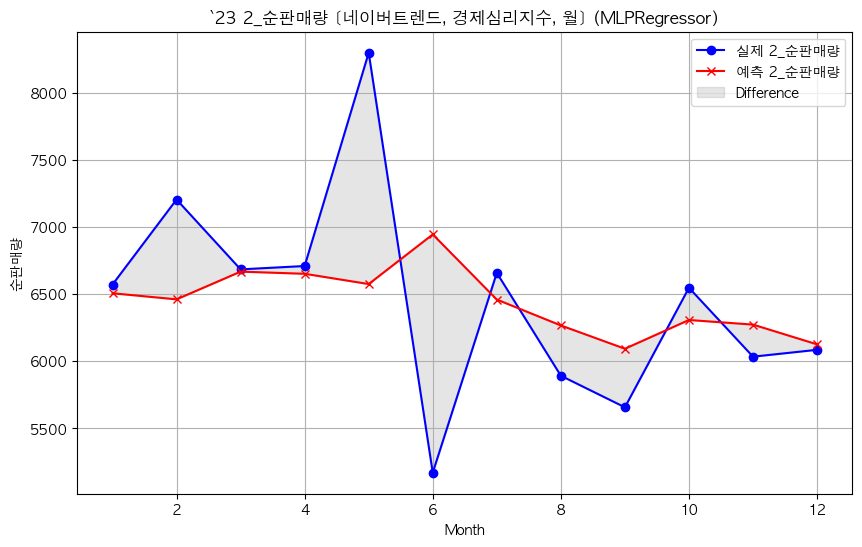

In [20]:
# 1. 데이터 불러오기 및 '날짜' 열에서 연도-월 정보 처리
df = pd.read_csv(file_path)
df['날짜'] = df['날짜'].str[:7]  # '날짜'에서 연도-월까지만 남김
df['월'] = pd.to_datetime(df['날짜']).dt.month  # 월 변수 추가

# 2. 원핫 인코딩 (One-Hot Encoding) 적용
df = pd.get_dummies(df, columns=['월'], drop_first=True)  # 원핫 인코딩 수행, 첫 번째 월은 제외

# 중복된 열이 있는지 확인하고, 중복된 열이 있으면 제거
df = df.loc[:, ~df.columns.duplicated()]  # 중복된 열 제거

# 3. '날짜' 열을 사용하여 2021년과 2022년 데이터만 학습에 사용하고 2023년 데이터는 예측에 사용
df_21_22 = df[df['날짜'].str[:4].isin(['2021', '2022'])] 
df_21_23 = df[df['날짜'].str[:4].isin(['2021', '2022', '2023'])] 
df_23_24 = df[df['날짜'].str[:4].isin(['2023', '2024'])] 
df_23 = df[df['날짜'].str[:4].eq('2023')] 
df_24 = df[df['날짜'].str[:4].eq('2024')] 

# 각 데이터셋에서도 중복된 열 제거
df_21_22 = df_21_22.loc[:, ~df_21_22.columns.duplicated()]
df_21_23 = df_21_23.loc[:, ~df_21_23.columns.duplicated()]
df_23_24 = df_23_24.loc[:, ~df_23_24.columns.duplicated()]
df_23 = df_23.loc[:, ~df_23.columns.duplicated()]
df_24 = df_24.loc[:, ~df_24.columns.duplicated()]

# 4. 독립 변수 (X)와 종속 변수 (y) 설정
# 원핫 인코딩된 '월' 변수를 포함하여 학습
X_21_22 = df_21_22[['네이버트렌드', '경제심리지수'] + [col for col in df_train_21_22.columns if '월_' in col]]
y_21_22 = df_21_22['2_순판매량']

X_21_23 = df_21_23[['네이버트렌드', '경제심리지수'] + [col for col in df_train_21_22.columns if '월_' in col]]
y_21_23 = df_21_23['2_순판매량']

X_23 = df_23[['네이버트렌드', '경제심리지수'] + [col for col in df_test_2023.columns if '월_' in col]]
y_23 = df_23['2_순판매량']

X_24 = df_24[['네이버트렌드', '경제심리지수'] + [col for col in df_test_2024.columns if '월_' in col]]

X_23_24 = df_23_24[['네이버트렌드', '경제심리지수'] + [col for col in df_test_2024.columns if '월_' in col]]

# 5. MLPRegressor 모델 설정 및 학습
mlp_model_21_22 = MLPRegressor(hidden_layer_sizes=(64, 32, 16), max_iter=500, random_state=42)
mlp_model_21_22.fit(X_21_22, y_21_22)

# 6. 2023년 데이터 예측
mlp_pred_2023 = mlp_model_21_22.predict(X_23)

mlp_pred_23_24 = mlp_model_21_22.predict(X_23_24)

mlp_model_21_23 = MLPRegressor(hidden_layer_sizes=(64, 32, 16), max_iter=500, random_state=42)
mlp_model_21_23.fit(X_21_23, y_21_23)

mlp_pred_24 = mlp_model_21_23.predict(X_24)


# 7. 성능 평가: MSE와 MAE 계산
mlp_mse = mean_squared_error(y_test, mlp_pred_2023)
mlp_mae = mean_absolute_error(y_test, mlp_pred_2023)
print(f"MLPRegressor 2023년 데이터의 MSE: {mlp_mse}")
print(f"MLPRegressor 2023년 데이터의 MAE: {mlp_mae}")

# 8. 실제값과 비교
if '2_순판매량' in df_23.columns:
    actual_2023 = df_23['2_순판매량'].values
else:
    actual_2023 = None
    print("2023년 데이터에 대한 실제값이 없으므로, 비교할 수 없습니다.")

# 9. 그래프 그리기
if actual_2023 is not None:
    months_2023 = np.arange(1, len(actual_2023) + 1)

    plt.figure(figsize=(10, 6))
    plt.plot(months_2023, actual_2023, label='실제 2_순판매량', marker='o', color='b')
    plt.plot(months_2023, mlp_pred_2023, label='예측 2_순판매량', marker='x', color='r')
    plt.fill_between(months_2023, actual_2023, mlp_pred_2023, color='gray', alpha=0.2, label='Difference')

    plt.xlabel('Month')
    plt.ylabel('순판매량')
    plt.title('`23 2_순판매량 [네이버트렌드, 경제심리지수, 월] (MLPRegressor)')
    plt.legend()
    plt.grid(True)
    plt.show()

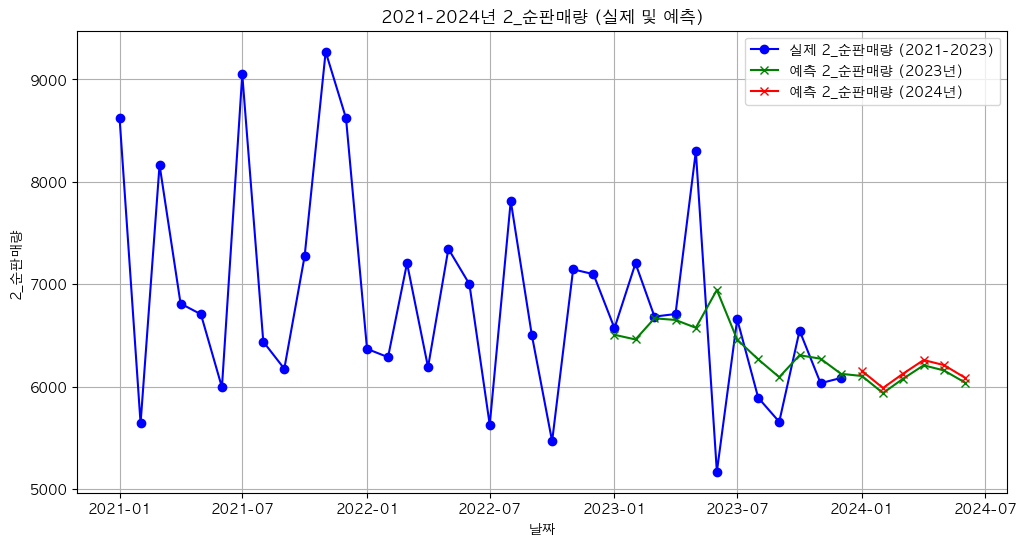

In [21]:
# 1. 2021~2023년 실제 데이터 추출 (2_순판매량으로 변경)
df_train_21_23 = df[df['날짜'].str[:4].isin(['2021', '2022', '2023'])]  # 학습 데이터: 2021년, 2022년, 2023년

# 날짜 및 2_순판매량 추출
dates_train = pd.to_datetime(df_train_21_23['날짜'])
sales_train = df_train_21_23['2_순판매량']

# 2. 2023년 예측 데이터 준비 (MLPRegressor 결과 사용)
dates_test_2023_24 = pd.to_datetime(df_23_24['날짜'])
sales_pred_2023_24 = mlp_pred_23_24  # MLP 모델에서 예측한 2023년 결과

# 3. 2024년 예측 데이터 준비 (MLPRegressor 결과 사용)
dates_test_2024 = pd.to_datetime(df_test_2024['날짜'])
sales_pred_2024 = mlp_pred_24  # MLP 모델에서 예측한 2024년 결과

# 4. 그래프 그리기
plt.figure(figsize=(12, 6))

# 2021~2023년 실제 데이터 그래프
plt.plot(dates_train, sales_train, label='실제 2_순판매량 (2021-2023)', marker='o', color='b')

# 2023년 예측 데이터 그래프
plt.plot(dates_test_2023_24, sales_pred_2023_24, label='예측 2_순판매량 (2023년)', marker='x', color='g')

# 2024년 예측 데이터 그래프
plt.plot(dates_test_2024, sales_pred_2024, label='예측 2_순판매량 (2024년)', marker='x', color='r')

# 그래프 설정
plt.xlabel('날짜')
plt.ylabel('2_순판매량')
plt.title('2021-2024년 2_순판매량 (실제 및 예측)')
plt.legend()
plt.grid(True)

# 그래프 표시
plt.show()
